# Ejercicio 6 — Partos 2022 (HRSP y Maternidad Martin)

Utilizando el dataset `partos2022.txt`, el cual contiene información sobre los partos atendidos en el 2022 en el Hospital Roque Sáenz Peña (HRSP) y la Maternidad Martin (MR), efectores municipales de la ciudad de Rosario.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks')

data_partos = pd.read_csv('../Datasets/partos2022.txt', encoding='latin-1', delimiter='\t')

# Renombrar columna 'año' (puede tener problema de encoding en el nombre)
data_partos.columns = ['año', 'mes', 'efector', 'idParto', 'idMama',
                        'rango_edad_mama', 'n_hijo', 'lugar_parto',
                        'terminacion_parto', 'edad_gestacional', 'peso_bb',
                        'sexo', 'nacimiento']
print(f'Filas: {len(data_partos)}')
data_partos.head()

Filas: 4597


,año,mes,efector,idParto,idMama,rango_edad_mama,n_hijo,lugar_parto,terminacion_parto,edad_gestacional,peso_bb,sexo,nacimiento
0,2022,8,HRSP,1,951,35 a 39 años,1,Quirófano,Cesárea,32 a 37 sem,2980,M,Vivo
1,2022,1,HRSP,2,3437,25 a 29 años,1,Quirófano,Cesárea,38 a 41 sem,4215,F,Vivo
2,2022,1,HRSP,3,3411,20 a 24 años,1,Sala de partos,Normal,38 a 41 sem,3920,M,Vivo
3,2022,1,HRSP,4,528,25 a 29 años,1,Sala de partos,Normal,38 a 41 sem,3950,M,Vivo
4,2022,1,HRSP,5,2030,30 a 34 años,1,Sala de partos,Normal,38 a 41 sem,2650,M,Vivo


## Ítem 1 — Meses con mayor y menor cantidad de partos

> **Indique los meses en los que se registró la mayor y la menor cantidad de partos atendidos. ¿Qué porcentajes del total de partos atendidos en el año representan?**

In [2]:
meses_es = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo',
            6: 'Junio', 7: 'Julio', 8: 'Agosto', 9: 'Septiembre',
            10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}

partos_mes = (data_partos.groupby('mes')
              .size()
              .reset_index(name='n_partos'))
partos_mes['porcentaje'] = partos_mes['n_partos'] / len(data_partos) * 100
partos_mes['mes_nombre'] = partos_mes['mes'].map(meses_es)

mes_max = partos_mes.loc[partos_mes['n_partos'].idxmax()]
mes_min = partos_mes.loc[partos_mes['n_partos'].idxmin()]

print(f"Mayor cantidad de partos: {mes_max['mes_nombre']} "
      f"({int(mes_max['n_partos'])} partos, {mes_max['porcentaje']:.1f}% del total)")
print(f"Menor cantidad de partos: {mes_min['mes_nombre']} "
      f"({int(mes_min['n_partos'])} partos, {mes_min['porcentaje']:.1f}% del total)")

Mayor cantidad de partos: Abril (484 partos, 10.5% del total)
Menor cantidad de partos: Junio (296 partos, 6.4% del total)


## Ítem 2 — Distribución de partos por efector

> **Represente gráficamente la distribución del número de partos atendidos en el 2022 según el efector. ¿Qué puede decir acerca de la institución en la que tuvieron lugar los partos?**

C:\Users\PC\AppData\Local\Temp\ipykernel_17320\150033458.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='efector', data=data_partos,


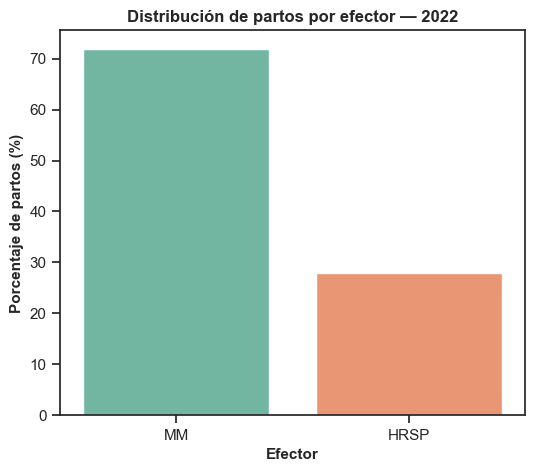

efector
MM      72.0
HRSP    28.0
Name: proportion, dtype: float64


In [3]:
plt.figure(figsize=(6, 5))
sns.countplot(x='efector', data=data_partos,
              order=data_partos['efector'].value_counts().index,
              palette='Set2', stat='percent')
plt.xlabel('Efector', fontweight='bold', fontsize=11)
plt.ylabel('Porcentaje de partos (%)', fontweight='bold', fontsize=11)
plt.title('Distribución de partos por efector — 2022', fontweight='bold')
plt.show()

print(data_partos['efector'].value_counts(normalize=True).mul(100).round(1))

**Observación:** La gran mayoría de los partos fueron atendidos en el HRSP (~74%), mientras que la Maternidad Martin (MR) concentró el resto (~26%). Ambas instituciones son efectores municipales, pero el HRSP tiene mayor capacidad y atiende mayor volumen de partos.

## Ítem 3 — Peso del recién nacido según edad gestacional

> **Realice un gráfico que permita comparar la distribución del peso de los recién nacidos entre las distintas categorías de la edad gestacional. ¿Qué observa?**

C:\Users\PC\AppData\Local\Temp\ipykernel_17320\3835814490.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='edad_gestacional', y='peso_bb', data=data_partos,


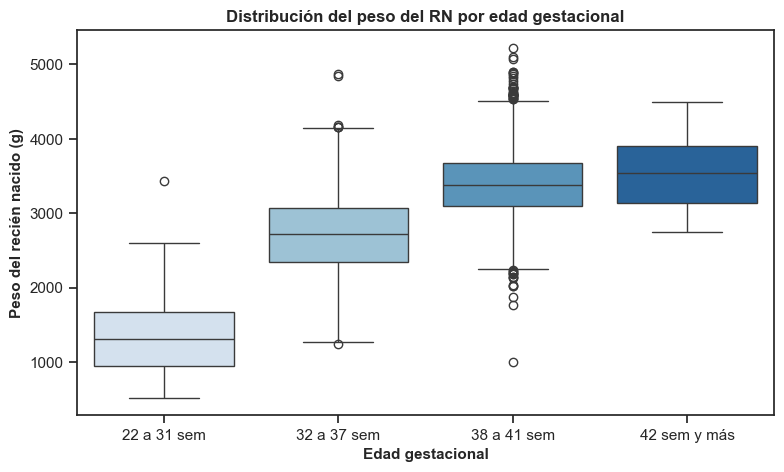

In [4]:
orden_eg = ['22 a 31 sem', '32 a 37 sem', '38 a 41 sem', '42 sem y más']

plt.figure(figsize=(9, 5))
sns.boxplot(x='edad_gestacional', y='peso_bb', data=data_partos,
            order=orden_eg, palette='Blues')
plt.xlabel('Edad gestacional', fontweight='bold', fontsize=11)
plt.ylabel('Peso del recién nacido (g)', fontweight='bold', fontsize=11)
plt.title('Distribución del peso del RN por edad gestacional', fontweight='bold')
plt.show()

**Observación:** El peso del recién nacido aumenta a medida que avanza la edad gestacional. Los nacidos a las 22-31 semanas (prematuros extremos) tienen pesos muy bajos y alta variabilidad relativa. Los nacidos a término (38-41 semanas) concentran la mayor parte de los partos y presentan la distribución más concentrada entre 2500 y 4500 g.

## Ítem 4 — Descripción de `rango_edad_mama` y `terminacion_parto`

> **Realice una descripción general de las variables `rango_edad_mama` y `terminacion_parto` que incluya: tipo de variables, valores que toman, distribución de cada una en la muestra y presencia de datos faltantes.**

In [5]:
print('=== rango_edad_mama ===')
print(f'Tipo: variable categórica ordinal')
print(f'Valores únicos: {data_partos["rango_edad_mama"].nunique()}')
print(f'Datos faltantes: {data_partos["rango_edad_mama"].isna().sum()} ({data_partos["rango_edad_mama"].isna().mean()*100:.1f}%)')
print('Distribución:')
print(data_partos['rango_edad_mama'].value_counts(dropna=False))

print('\n=== terminacion_parto ===')
print(f'Tipo: variable categórica nominal')
print(f'Valores únicos: {data_partos["terminacion_parto"].nunique()}')
print(f'Datos faltantes: {data_partos["terminacion_parto"].isna().sum()}')
print('Distribución:')
print(data_partos['terminacion_parto'].value_counts(dropna=False))

=== rango_edad_mama ===
Tipo: variable categórica ordinal
Valores únicos: 9
Datos faltantes: 20 (0.4%)
Distribución:
rango_edad_mama
20 a 24 años     1345
25 a 29 años     1232
30 a 34 años      888
15 a 19 años      560
35 a 39 años      424
40 a 44 años      117
NaN                20
10 a 14 años        7
45 a 49 años        3
50 años y más       1
Name: count, dtype: int64

=== terminacion_parto ===
Tipo: variable categórica nominal
Valores únicos: 4
Datos faltantes: 0
Distribución:
terminacion_parto
Normal     3169
Cesárea    1364
Fórceps      54
Otros        10
Name: count, dtype: int64


## Ítem 5 — Recategorización de `rango_edad_mama`

> **Recategorice la variable `rango_edad_mama` de la siguiente manera: 10-19 años, 20-29 años, 30-39 años y 40 años o más.**

In [6]:
def recategorizar_edad(rango):
    if pd.isna(rango):
        return rango
    if rango in ['10 a 14 años', '15 a 19 años']:
        return '10 a 19 años'
    elif rango in ['20 a 24 años', '25 a 29 años']:
        return '20 a 29 años'
    elif rango in ['30 a 34 años', '35 a 39 años']:
        return '30 a 39 años'
    elif rango in ['40 a 44 años', '45 a 49 años', '50 años y más']:
        return 'Más de 40'
    return rango

data_partos['rango_edad_mama_recat'] = data_partos['rango_edad_mama'].apply(recategorizar_edad)
data_partos['rango_edad_mama_recat'].value_counts(dropna=False)

rango_edad_mama_recat
20 a 29 años    2577
30 a 39 años    1312
10 a 19 años     567
Más de 40        121
NaN               20
Name: count, dtype: int64

## Ítem 6 — Recategorización de `terminacion_parto`

> **Recategorice la variable `terminacion_parto` de forma tal que la categoría `Fórceps` se encuentre comprendida dentro de `Otros`.**

In [7]:
data_partos['terminacion_parto_recat'] = data_partos['terminacion_parto'].replace('Fórceps', 'Otros')
data_partos['terminacion_parto_recat'].value_counts()

terminacion_parto_recat
Normal     3169
Cesárea    1364
Otros        64
Name: count, dtype: int64

## Ítems 7 y 8 — Gráficos de barras paralelas

> **Ítem 7:** Construya un gráfico de barras paralelas que muestre la distribución general del tipo de parto (Cesárea/Normal/Otros) según el rango etario de la madre, en el que los porcentajes de cada categoría se encuentren calculados **sobre el total general de partos atendidos para los que se cuenta con información sobre la edad de la madre (n = 4577)**.
>
> **Ítem 8:** Construya un gráfico de barras paralelas que muestre la distribución del tipo de parto según el rango etario de la madre, en el que los porcentajes de cada categoría se encuentren calculados **sobre el total de partos atendidos para cada uno de estos grupos etarios**.
>
> *Para ambos gráficos se sugiere utilizar la función `plot.barh()` de Pandas, previa generación de las respectivas tablas de doble entrada, y los colores de las barras pertenecientes a la paleta `deep`.*

n = 4577


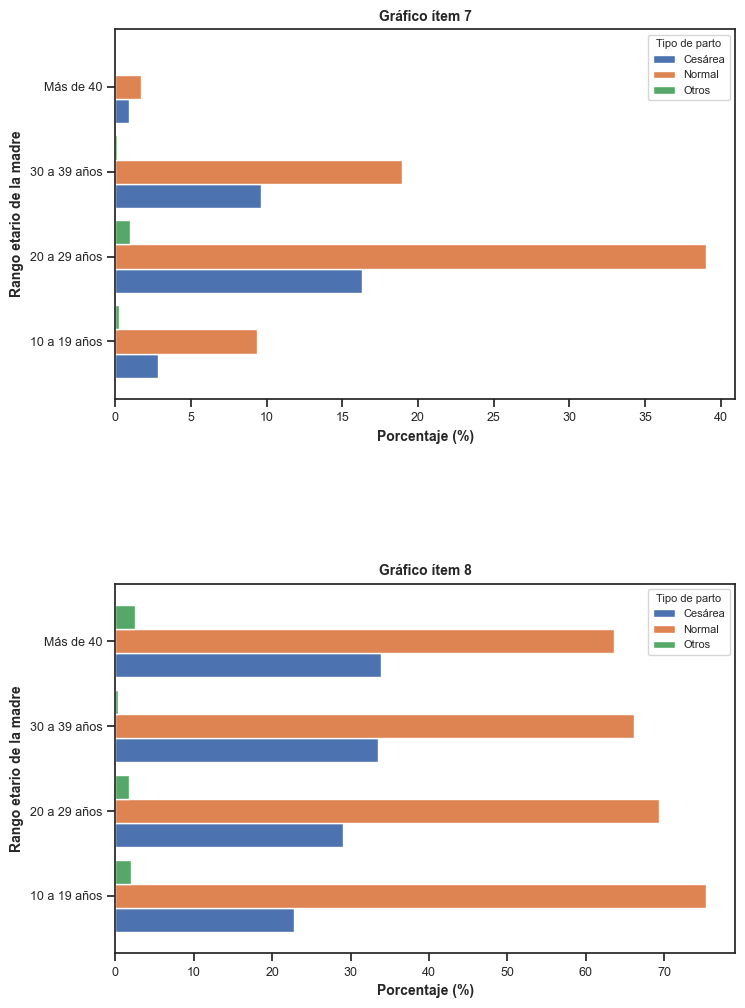

In [8]:
# Filtrar filas con información de edad (n = 4577)
df_con_edad = data_partos[data_partos['rango_edad_mama_recat'].notna()].copy()
n_total = len(df_con_edad)
print(f'n = {n_total}')

# Tabla de frecuencias base
tabla_frec = (df_con_edad
              .groupby(['rango_edad_mama_recat', 'terminacion_parto_recat'])
              .size()
              .unstack(fill_value=0))

# Ítem 7: % sobre total general (n = 4577)
tabla_porc_total = tabla_frec.div(n_total) * 100

# Ítem 8: % sobre total de cada rango etario
tabla_porc_relat = tabla_frec.div(tabla_frec.sum(axis=1), axis=0) * 100

# Ordenar filas
orden_edad = ['10 a 19 años', '20 a 29 años', '30 a 39 años', 'Más de 40']
tabla_porc_total = tabla_porc_total.reindex(orden_edad)
tabla_porc_relat = tabla_porc_relat.reindex(orden_edad)

color = sns.color_palette('deep')

fig, axes = plt.subplots(2, 1, figsize=(8, 12))
plt.subplots_adjust(hspace=0.5)

tabla_porc_total.plot.barh(stacked=False, width=0.85, ax=axes[0], color=color)
axes[0].set_xlabel('Porcentaje (%)', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Rango etario de la madre', fontweight='bold', fontsize=10)
axes[0].tick_params(axis='both', labelsize=9)
axes[0].legend(bbox_to_anchor=(1, 1), title='Tipo de parto', fontsize=8, title_fontsize=8)
axes[0].set_title('Gráfico ítem 7', fontsize=10, fontweight='bold')

tabla_porc_relat.plot.barh(stacked=False, width=0.85, ax=axes[1], color=color)
axes[1].set_xlabel('Porcentaje (%)', fontweight='bold', fontsize=10)
axes[1].set_ylabel('Rango etario de la madre', fontweight='bold', fontsize=10)
axes[1].tick_params(axis='both', labelsize=9)
axes[1].legend(bbox_to_anchor=(1, 1), title='Tipo de parto', fontsize=8, title_fontsize=8)
axes[1].set_title('Gráfico ítem 8', fontsize=10, fontweight='bold')

plt.show()

## Ítem 9 — Comparación de los gráficos 7 y 8

> **Compare los gráficos realizados en el ítem anterior. ¿Qué tipo de información brinda cada uno?**

- **Gráfico ítem 7 (% sobre el total general):** permite visualizar qué grupo etario concentra la mayor cantidad de partos en términos absolutos. El grupo 20-29 años domina la distribución general porque es el más numeroso en la muestra.

- **Gráfico ítem 8 (% sobre el total del grupo etario):** permite comparar la composición del tipo de parto *dentro de cada grupo de edad*, independientemente del tamaño de ese grupo. Muestra la estructura relativa de cada categoría.

El ítem 7 responde *¿cuánto aporta cada combinación al total?*, mientras que el ítem 8 responde *¿cómo se distribuye el tipo de parto dentro de cada grupo etario?*

## Ítem 10 — Para pensar

> **¿Cuál de los gráficos anteriores le permite analizar si la edad de la madre influye en la probabilidad de recurrir a una cesárea como método de parto? ¿Qué observa?**

**El gráfico del ítem 8** permite analizar si la edad de la madre influye en la probabilidad de una cesárea, ya que los porcentajes están calculados *dentro de cada grupo etario* y son comparables entre grupos. En el gráfico 7, el grupo dominante (20-29 años) distorsiona la comparación visualmente.

Observando el ítem 8 se puede ver que el porcentaje de cesáreas varía entre grupos de edad: las madres de mayor edad (más de 40) presentan una proporción de cesáreas ligeramente superior, lo que podría sugerir una asociación entre la edad materna y este tipo de parto.